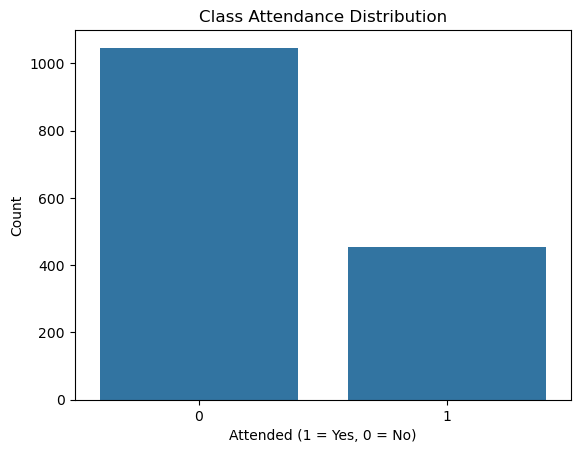

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82       197
           1       0.68      0.49      0.57       103

    accuracy                           0.75       300
   macro avg       0.73      0.68      0.69       300
weighted avg       0.74      0.75      0.73       300



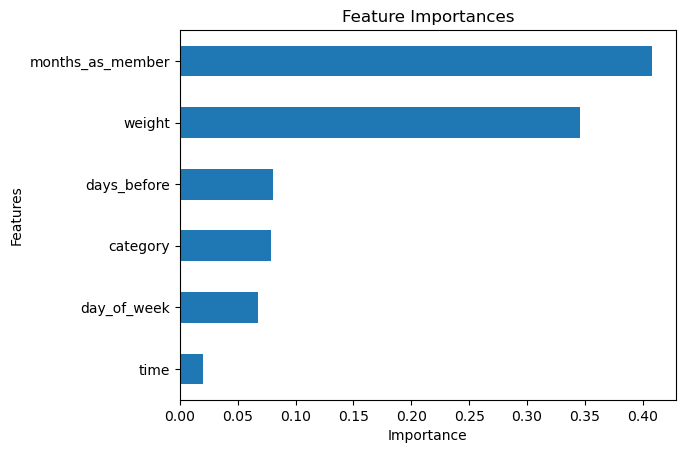

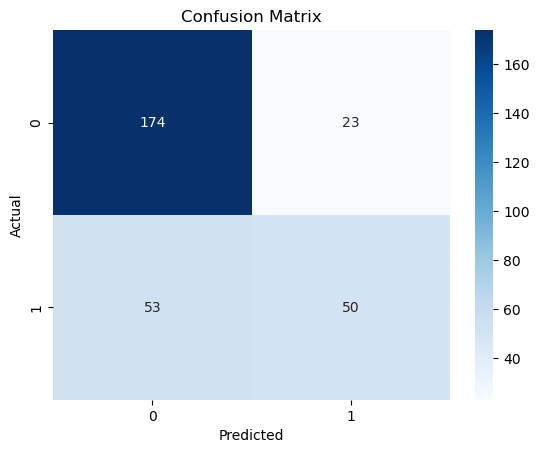

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
# Load Problem A data
problem1_df = pd.read_csv("C:/Users/goswa/Downloads/problem2.csv")

# Impute missing weights
imputer = SimpleImputer(strategy="mean")
problem1_df["weight"] = imputer.fit_transform(problem1_df[["weight"]])

# Encode categorical columns
categorical_cols = ["days_before", "day_of_week", "time", "category"]
for col in categorical_cols:
    le = LabelEncoder()
    problem1_df[col] = le.fit_transform(problem1_df[col])

# === EDA: Visualizations ===
# 1. Attendance distribution
sns.countplot(data=problem1_df, x="attended")
plt.title("Class Attendance Distribution")
plt.xlabel("Attended (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

# Define features and target
X1 = problem1_df.drop(columns=["booking_id", "attended"])
y1 = problem1_df["attended"]

# Train-test split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Model training
clf = RandomForestClassifier(random_state=42)
clf.fit(X1_train, y1_train)

# Evaluation
y1_pred = clf.predict(X1_test)
print("Classification Report:\n", classification_report(y1_test, y1_pred))

# === Feature Importance Plot ===
feature_importances = pd.Series(clf.feature_importances_, index=X1.columns)
feature_importances.sort_values().plot(kind='barh')
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# === Confusion Matrix ===
cm = confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


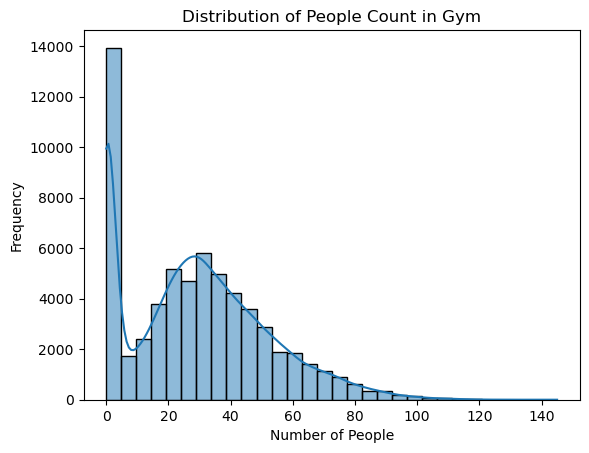

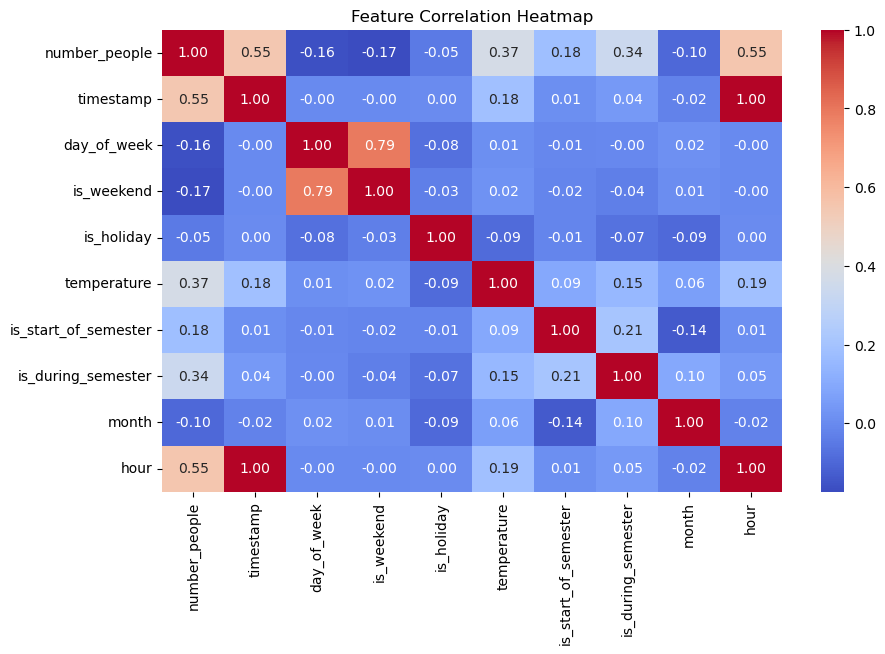

Mean Squared Error: 42.41418496647134
R² Score: 0.9179367829053184


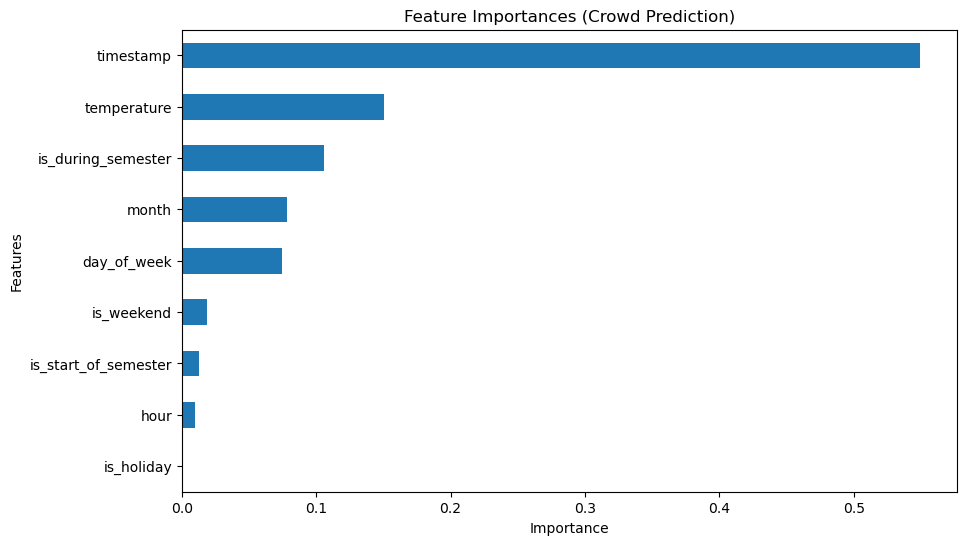

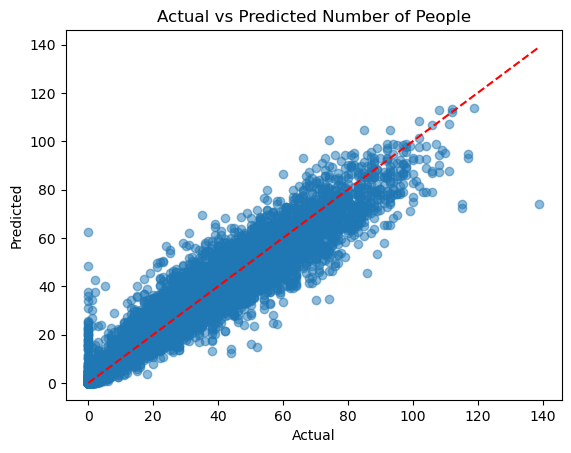

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Problem B data
problem2_df = pd.read_csv("C:/Users/goswa/Downloads/problem1.csv")

# === EDA: Visualizations ===
# 1. Target distribution
sns.histplot(problem2_df["number_people"], bins=30, kde=True)
plt.title("Distribution of People Count in Gym")
plt.xlabel("Number of People")
plt.ylabel("Frequency")
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(problem2_df.drop(columns=["date"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Define features and target
X2 = problem2_df.drop(columns=["number_people", "date"])
y2 = problem2_df["number_people"]

# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Model training
reg = RandomForestRegressor(random_state=42)
reg.fit(X2_train, y2_train)

# Prediction and evaluation
y2_pred = reg.predict(X2_test)
mse = mean_squared_error(y2_test, y2_pred)
r2 = r2_score(y2_test, y2_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

# === Feature Importance Plot ===
feature_importances = pd.Series(reg.feature_importances_, index=X2.columns)
feature_importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Feature Importances (Crowd Prediction)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# === Actual vs Predicted Plot ===
plt.scatter(y2_test, y2_pred, alpha=0.5)
plt.title("Actual vs Predicted Number of People")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
plt.show()
